<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula25a_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

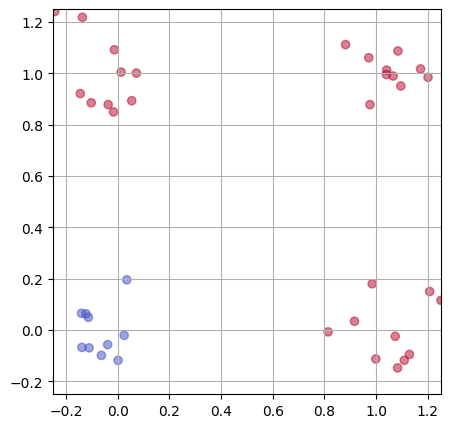

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

n_samples = 40

def generateLogicalDataset(n_samples,
                           func=lambda a, b: bool(a) or bool(b)):
    X, y = make_blobs(n_samples=n_samples,
                      centers=[[0,0],[1,0],[1,1],[0,1]],
                      cluster_std=0.1)
    y = np.array([func(a>0.5, b>0.5) for a, b in zip(X[:,0], X[:,1])], dtype=int) * 2 -1
    return X, y

def plotDataset(X, y, xlim=(-0.25, 1.25), ylim=(-0.25, 1.25)):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', alpha=0.5, cmap="coolwarm")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True)

def plotHyperplan(weights, bias):
    xs = np.array([-11, 11])
    ys = -(weights[0]*xs + bias)/weights[1]
    plt.plot(xs, ys, '--')

X, y = generateLogicalDataset(n_samples)
plotDataset(X, y)
plt.show()

Accuracy: 1.0
Weights: 
array([[-0.40892003],
       [ 0.87443621],
       [ 0.94918165]])


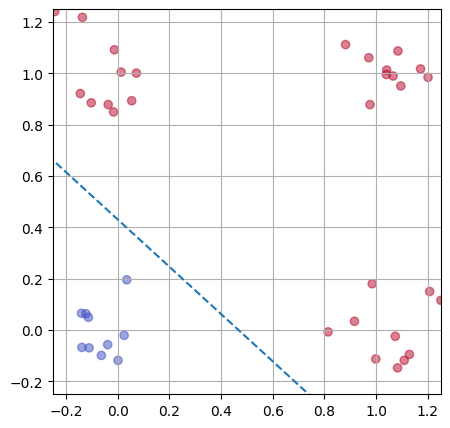

In [ ]:
class WidrowHoff():
  def getCost(self, y, y_pred):
    return np.mean((y - y_pred)**2)
  def getGradient(self, y, y_pred, X):
    return X.T @ (y - y_pred)

class GradientDescent():
  def __init__(self, max_iter=1000, learning_rate=0.001, cost=WidrowHoff()):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.cost = cost
  def getW(self, X, y):
    w = np.random.uniform(size=(X.shape[1],y.shape[1]))
    for _ in range(self.max_iter):
      y_pred = X @ w
      w += self.cost.getGradient(y, y_pred, X) * self.learning_rate
    return w

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer
from pprint import pprint

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class ShallowNeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    self.label_binarizer = LabelBinarizer()
    y = self.label_binarizer.fit_transform(y)
    y = np.where(y == 1, 1, -1)
    X = include_bias(X)
    self.w = self.trainingAlgorithm.getW(X, y)
    return self

  def pre_activation(self, X):
    logits = X @ self.w
    return logits

  def predict(self, X):
    X = include_bias(X)
    y_pred = self.pre_activation(X)
    if y_pred.shape[1] == 1:
      y_pred = np.where(y_pred > 0, 1, -1)
    y_pred = self.label_binarizer.inverse_transform(y_pred)
    return y_pred

model = ShallowNeuralNetwork(GradientDescent())
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: ")
pprint(model.w)
plotDataset(X, y)
for i in range(model.w.shape[1]):
  plotHyperplan(model.w[1:, i], model.w[0,i])
plt.show()

Accuracy: 1.0
Weights: 
array([[-1.51217331],
       [ 0.94496139],
       [ 1.06528358]])


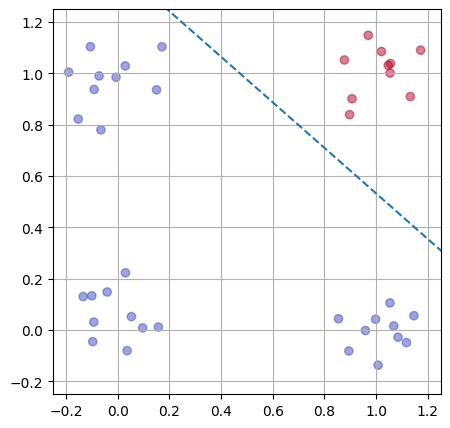

In [ ]:
X, y = generateLogicalDataset(n_samples, func=lambda a, b: bool(a) and bool(b))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: ")
pprint(model.w)
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plt.show()

Accuracy: 0.5
Weights: 
array([[-0.01997764],
       [ 0.00395311],
       [ 0.03739849]])


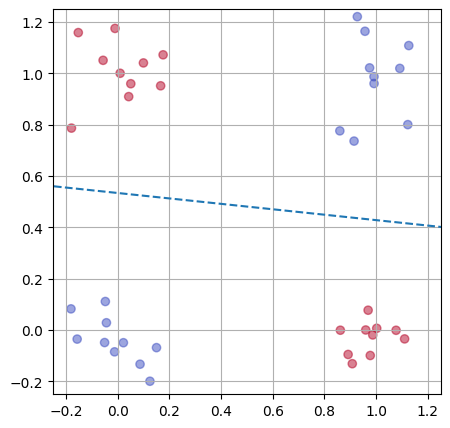

In [ ]:
X, y = generateLogicalDataset(n_samples, func=lambda a, b: bool(a) != bool(b))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: ")
pprint(model.w)
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plt.show()

In [ ]:
class XORClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        pass
    def predict(self, X):
        Xb = include_bias(X)
        self.ihw = np.array([[0.5, -1, 1], [0.5, 1 ,-1]]).T
        self.pH = Xb @ self.ihw
        self.H = np.sign(self.pH)
        Hb = include_bias(self.H)
        self.how = np.array([0.5, -1, -1])
        y_pred = Hb @ self.how
        return np.sign(y_pred)

model = XORClassifier()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")

Accuracy: 1.0


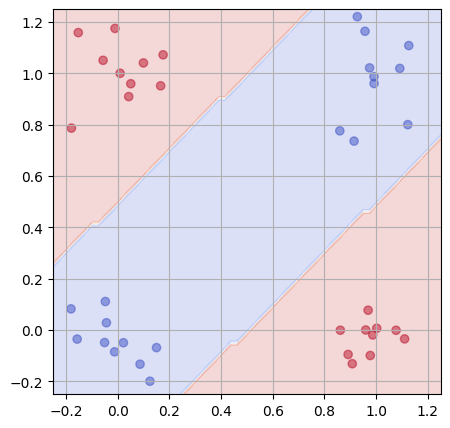

In [ ]:
def defineAxes(X):
  offset = 0.5
  min0, max0 = X[:, 0].min(), X[:, 0].max()
  min1, max1 = X[:, 1].min(), X[:, 1].max()
  return [min0-offset, max0+offset], [min1-offset, max1+offset]

def plotPredictions(model, X):
  axis0, axis1 = defineAxes(X)
  x0s = np.linspace(axis0[0], axis0[1], 100)
  x1s = np.linspace(axis1[0], axis1[1], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap='coolwarm', alpha=0.2)

plotDataset(X, y)
plotPredictions(model, X)
plt.show()

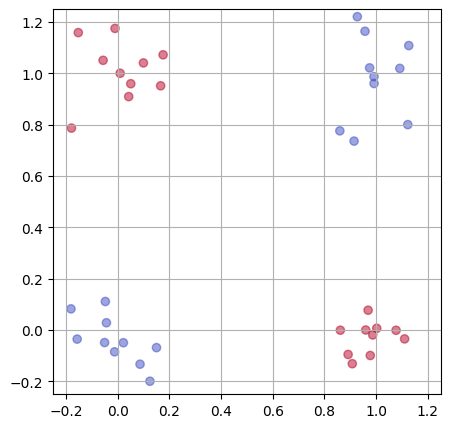

In [ ]:
plotDataset(X, y)
plt.show()

In [ ]:
model = XORClassifier()
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")

Accuracy: 1.0


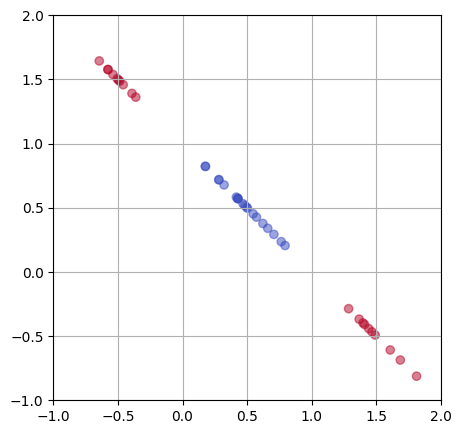

In [ ]:
plotDataset(model.pH, y, xlim=(-1, 2), ylim=(-1, 2))
plt.show()

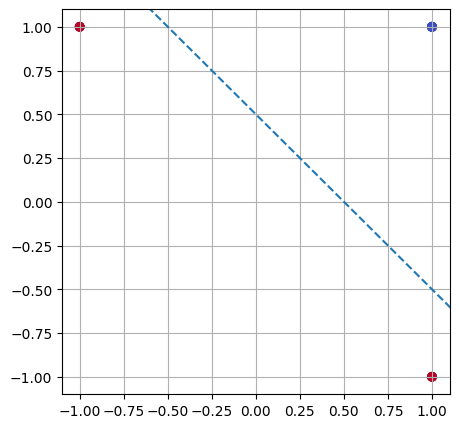

In [ ]:
plotDataset(model.H, y, xlim=(-1.1, 1.1), ylim=(-1.1, 1.1))
plotHyperplan(model.how[1:], model.how[0])
plt.show()

In [ ]:
class XORClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        pass
    def predict(self, X):
        Xb = include_bias(X)
        self.ihw = np.array([[0.5, -1, 1], [0.5, 1 ,-1]]).T
        self.how = np.array([0.6, -0.9, -0.9])
        self.pH = Xb @ self.ihw
        self.H = np.tanh(self.pH)
        Hb = include_bias(self.H)
        y_pred = Hb @ self.how
        return np.sign(y_pred)

model = XORClassifier()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")

Accuracy: 1.0


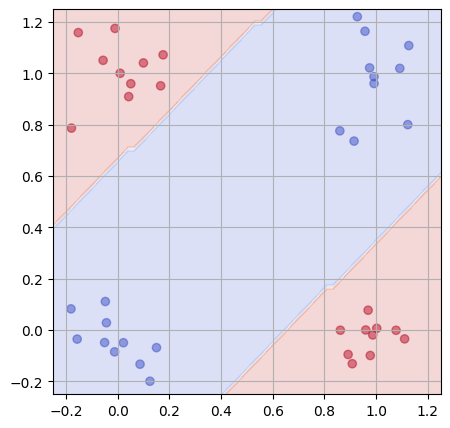

In [ ]:
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

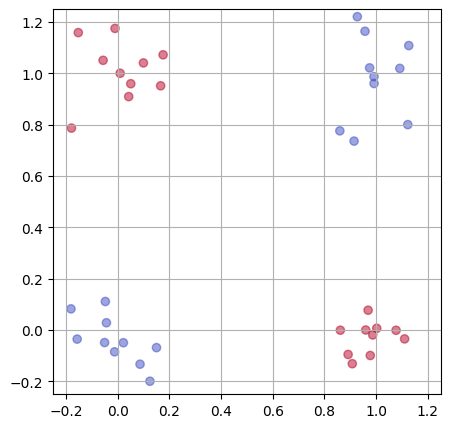

In [ ]:
plotDataset(X, y)
plt.show()

In [ ]:
model = XORClassifier()
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")

Accuracy: 1.0


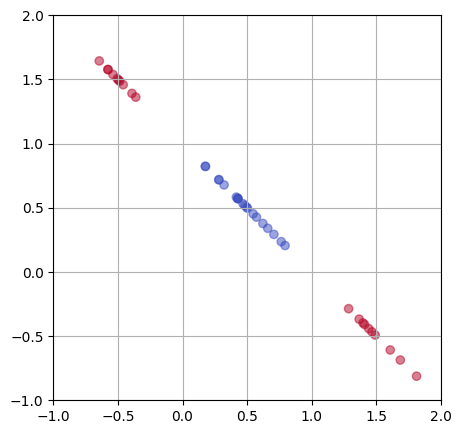

In [ ]:
plotDataset(model.pH, y, xlim=(-1, 2), ylim=(-1, 2))
plt.show()

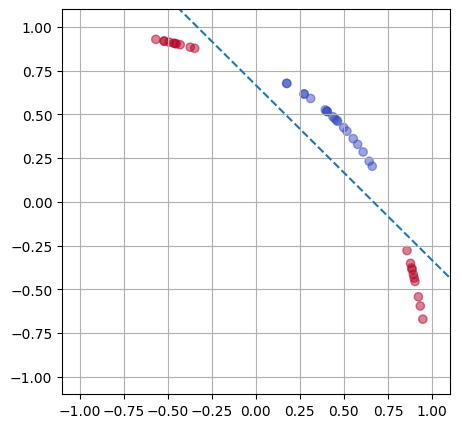

In [ ]:
plotDataset(model.H, y, xlim=(-1.1, 1.1), ylim=(-1.1, 1.1))
plotHyperplan(model.how[1:], model.how[0])
plt.show()